<a href="https://colab.research.google.com/github/jaewoo0108/ml/blob/main/week08-decision-trees/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8 - Decision Trees & Ensembles

(Titanic 승객 생존 데이터 사용)
- Entropy
- Information Gain
- Decision Tree
- Random Forest
- XGBoost

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

In [ ]:
# 데이터 로드, feature 선택
df = sns.load_dataset('titanic')
cols = ['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']
df = df[cols].copy()

print("shape :", df.shape)
print(df.head())
print(df.isna().sum())

# 결측치(NaN)을 채우기
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
print("남은 결측치 총합:", df.isna().sum().sum())

shape : (891, 6)
   survived  pclass     sex   age     fare embarked
0         0       3    male  22.0   7.2500        S
1         1       1  female  38.0  71.2833        C
2         1       3  female  26.0   7.9250        S
3         1       1  female  35.0  53.1000        S
4         0       3    male  35.0   8.0500        S
survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
dtype: int64
남은 결측치 총합: 0


In [ ]:
# 문자/범주형 데이터를 가지는 특성을 확인하고 one-hot 인코딩 적용

print(df.describe(include='object')) # .describe()메소드는 데이터 타입이 문자열/범주형인 열들만 골라서 요약 통계 보여준다
print(df.nunique()) # 전체 데이터셋의 특성마다 고유값 개수 출력하기

# 범주형 feature 3개를 0/1 이진 열들로 변환
df_encoded = pd.get_dummies(df, columns=['sex','pclass','embarked'], dtype=int)
print("변환 후 데이터:")
print(list(df_encoded.columns))
print(df_encoded.shape)

         sex embarked
count    891      891
unique     2        3
top     male        S
freq     577      646
survived      2
pclass        3
sex           2
age          88
fare        248
embarked      3
dtype: int64
변환 후 데이터:
['survived', 'age', 'fare', 'sex_female', 'sex_male', 'pclass_1', 'pclass_2', 'pclass_3', 'embarked_C', 'embarked_Q', 'embarked_S']
(891, 11)


In [ ]:
# Split Dataset into train / val / test (6 : 2 : 2)

X = df_encoded.drop(columns = ['survived'])
y = df_encoded['survived']
feature_names = list(X.columns)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state=42, stratify=y_temp)

print("train:", len(y_train), "val:", len(y_val), "test:", len(y_test))


train: 534 val: 178 test: 179


In [ ]:
# Entropy : 불순도를 숫자로 표현 (p는 해당 노드에서 양성 비율)
# H(p) = -p * log_2(p) - (1-p) * log_2(1-p)

def entropy(p):
  if p == 0 or p == 1:
    return 0
  return -p * np.log2(p) - (1-p) * np.log2(1-p)

print("H(0):",entropy(0))
print("H(0.5):",entropy(0.5))
print("H(root_p):",round(entropy(y_train.mean()),4))

H(0): 0
H(0.5): 1.0
H(root_p): 0.9607


In [ ]:
# Information Gain : 각 노드에서 어떤 feature를 기준으로 나눌지 결정
# IG = H(p_root) - (w_left * H(p_left) + w_right * H(p_right))

def information_gain(X, y, col):
  left = X[col] == 1
  right = X[col] == 0

  p_root = y.mean()
  p_left = y[left].mean() if left.sum() > 0 else 0
  p_right = y[right].mean() if right.sum() > 0 else 0
  w_left = left.sum() / len(X)
  w_right = right.sum() / len(X)

  IG = entropy(p_root) - (w_left * entropy(p_left) + w_right * entropy(p_right))
  return IG

binary_cols = [c for c in feature_names if set(X_train[c].unique()) <= {0,1}]
igs = {c: information_gain(X_train,y_train, c) for c in binary_cols}
for c in sorted(igs, key=igs.get, reverse=True):
  print(f"{c:14s} IG: {igs[c]:.4f}")

sex_female     IG: 0.2078
sex_male       IG: 0.2078
pclass_3       IG: 0.0700
pclass_1       IG: 0.0548
embarked_S     IG: 0.0206
embarked_C     IG: 0.0192
pclass_2       IG: 0.0054
embarked_Q     IG: 0.0010


In [ ]:
# 임계값 찾아서 연속형 특성(age, fare) 처리하기
# 정렬된 값들에서 중점을 후보로 놓고 IG 계산

def ig_continuous(X, y, col, thr):
  left = X[col] <= thr
  right = X[col] > thr
  p_root = y.mean()
  p_left = y[left].mean() if left.sum() > 0 else 0
  p_right = y[right].mean() if right.sum() > 0 else 0
  w_left = left.sum() / len(X)
  w_right = right.sum() / len(X)
  return entropy(p_root) - (w_left * entropy(p_left) + w_right * entropy(p_right))

# age, fare의 인접 중점들을 후보로 만들어서 전부 시도
age_vals = np.sort(X_train['age'].unique())
age_mids = (age_vals[:-1] + age_vals[1:]) / 2

fare_vals = np.sort(X_train['fare'].unique())
fare_mids = (fare_vals[:-1] + fare_vals[1:]) / 2

best_thr_age, best_ig_age = None, -1
best_thr_fare, best_ig_fare = None, -1
for t in age_mids:
  g = ig_continuous(X_train,y_train,'age',t)
  if g > best_ig_age:
    best_ig_age, best_thr_age = g, t

for j in fare_mids:
  h = ig_continuous(X_train,y_train,'fare',j)
  if h > best_ig_fare:
    best_ig_fare, best_thr_fare = h, j

print(f"age 최적 임계값 : {best_thr_age:.1f}세, (IG={best_ig_age:.4f})")
print(f"fare 최적 임계값 : {best_thr_fare:.1f}세, (IG={best_ig_fare:.4f})")

age 최적 임계값 : 7.5세, (IG=0.0345)
fare 최적 임계값 : 52.3세, (IG=0.0676)


sklearn이 고른 root 특성: sex_female


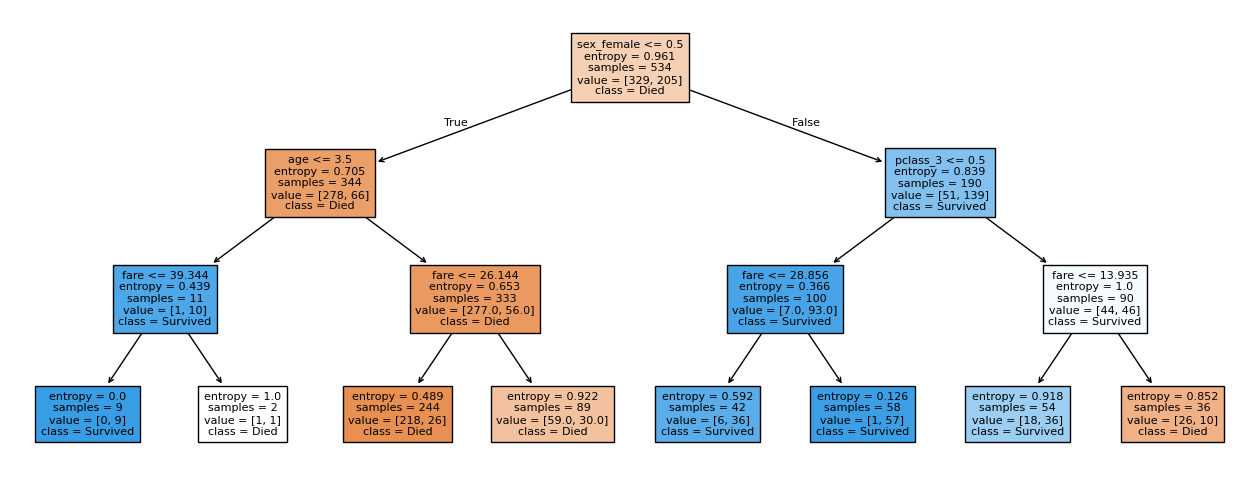

In [ ]:
# Using sklearn DeicisionTreeClassifier

model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
model.fit(X_train, y_train)

root_feature = feature_names[model.tree_.feature[0]]
print("sklearn이 고른 root 특성:", root_feature)

plt.figure(figsize=(16,6))
plot_tree(model, feature_names=feature_names, class_names=["Died","Survived"], filled=True, fontsize=8)
plt.show()

depth= 1, train=0.781 val=0.803
depth= 2, train=0.798 val=0.798
depth= 3, train=0.828 val=0.803
depth= 4, train=0.843 val=0.798
depth= 5, train=0.856 val=0.809
depth= 7, train=0.906 val=0.798
depth=10, train=0.946 val=0.781
depth=15, train=0.979 val=0.764
depth=20, train=0.979 val=0.758


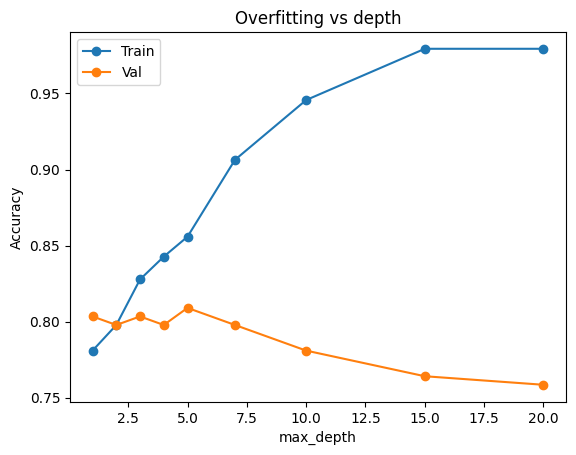

In [ ]:
# Tree의 깊이와 과적합 관계(max_depth)

depths = [1, 2, 3, 4, 5, 7, 10, 15, 20]
train_acc, val_acc = [], []
for d in depths:
  m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
  train_acc.append(m.score(X_train,y_train))
  val_acc.append(m.score(X_val,y_val))
  print(f"depth={d:2d}, train={train_acc[-1]:.3f} val={val_acc[-1]:.3f}")

plt.plot(depths, train_acc, marker='o', label="Train")
plt.plot(depths, val_acc, marker='o', label="Val")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Overfitting vs depth")
plt.show()

In [ ]:
# Single Tree vs Tree Ensemble(Random forest)
# 데이터 자체에 노이즈가 적기 때문에 앙상블 효과가 거의 없다
single = DecisionTreeClassifier(random_state=42).fit(X_train,y_train)
forest = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train,y_train)

print("single tree test", round(single.score(X_test, y_test), 3))
print("Randomforest test", round(forest.score(X_test, y_test), 3))

single tree test 0.832
Randomforest test 0.821


In [ ]:
# Using XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=500,learning_rate=0.1,early_stopping_rounds=10,eval_metric="logloss",random_state=42)
xgb.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)

print("실제로 멈춘 트리 개수 (best_iteration);", xgb.best_iteration)
print("test:", round(xgb.score(X_test, y_test),3))

실제로 멈춘 트리 개수 (best_iteration); 32
test: 0.821


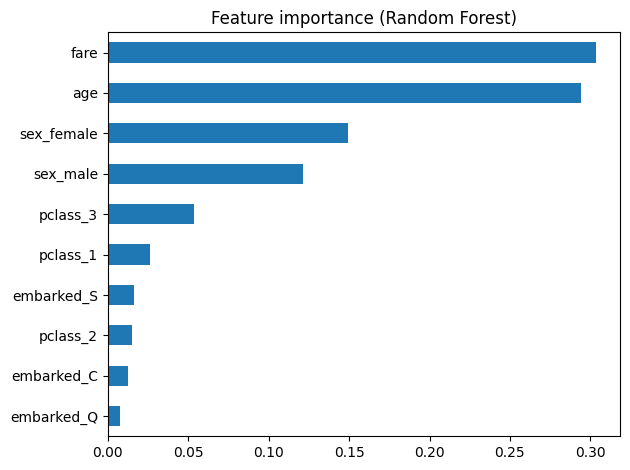

fare          0.303
age           0.294
sex_female    0.149
sex_male      0.121
pclass_3      0.054
pclass_1      0.026
embarked_S    0.016
pclass_2      0.015
embarked_C    0.013
embarked_Q    0.008
dtype: float64


In [ ]:
# 랜덤포레스트에서의 특성 중요도 확인하기

imp = pd.Series(forest.feature_importances_, index= feature_names).sort_values()
imp.plot(kind='barh')
plt.title("Feature importance (Random Forest)")
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False).round(3))